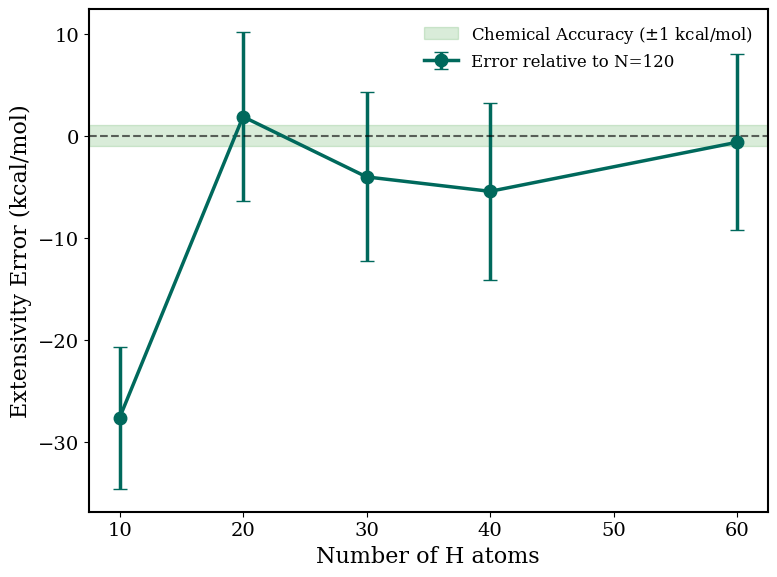

In [2]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif',
    'figure.dpi': 100
})

HA_TO_KCAL = 627.509

# =============================================================================
# 1. BULLETPROOF DATA EXTRACTION
# =============================================================================
data = []
dirs = glob.glob("../H_*_GNN-MB")

for d in dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N": n_atoms, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        pass

data = sorted(data, key=lambda x: x["N"])

valid_data = []
for d in data:
    has_gnn_blocks = "raw_block_energies" in d["gnn"].get("results", {})
    has_class_blocks = "raw_block_energies" in d["classical"].get("results", {})
    
    if has_gnn_blocks and has_class_blocks:
        valid_data.append(d)
    else:
        print(f"⚠️ Warning: 'raw_block_energies' missing for H_{d['N']}. Skipping.")

data = valid_data 
N_vals = np.array([d["N"] for d in data])

if len(N_vals) == 0:
    print("Error: No valid JSON files with 'raw_block_energies' found. Exiting.")
    exit()

# =============================================================================
# 2. PAIRED ENERGY DIFFERENCE EXTRACTION
# =============================================================================
# Since the runs share a seed and initial state, we subtract the blocks 
# BEFORE reblocking to correctly account for the covariance.
diff_E_list, diff_err_list = [], []

for d in data:
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"]).flatten()
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"]).flatten()
    
    # Paired array subtraction
    e_diff_array = raw_gnn - raw_class
    
    try:
        df_diff = reblock_by_autocorr(e_diff_array, name="E_Diff", verbose=0)
    except TypeError:
        df_diff = reblock_by_autocorr(e_diff_array, verbose=0)
        
    diff_E_list.append(float(df_diff.iloc[0, 0]))
    diff_err_list.append(float(df_diff.iloc[0, 1]))

diff_E = np.array(diff_E_list)
diff_err = np.array(diff_err_list)

# =============================================================================
# 3. THERMODYNAMIC LIMIT CONVERGENCE MATHEMATICS
# =============================================================================
TARGET_N = 120 # Our largest system to test against

if TARGET_N not in N_vals:
    print(f"Error: Target N={TARGET_N} not found in data.")
    exit()

target_idx = np.where(N_vals == TARGET_N)[0][0]
target_diff_E = diff_E[target_idx]
target_diff_err = diff_err[target_idx]

# Define the reference sizes we want to test
test_base_sizes = [10, 20, 30, 40, 60] 

base_sizes_plotted = []
extensivity_errors = []
extensivity_error_bars = []

for base_n in test_base_sizes:
    if base_n in N_vals:
        base_idx = np.where(N_vals == base_n)[0][0]
        
        # How many times does the base fit into the target?
        scale_factor = TARGET_N / base_n
        
        # Extensivity Deviation at N=120 (NO ABSOLUTE VALUE)
        dev_at_target = (target_diff_E - (scale_factor * diff_E[base_idx])) * HA_TO_KCAL
        
        # Propagate error: sigma = sqrt(sigma_target^2 + (scale * sigma_base)^2)
        err_at_target = np.sqrt(target_diff_err**2 + (scale_factor * diff_err[base_idx])**2) * HA_TO_KCAL
        
        base_sizes_plotted.append(base_n)
        extensivity_errors.append(dev_at_target) 
        extensivity_error_bars.append(err_at_target)

base_sizes_plotted = np.array(base_sizes_plotted)
extensivity_errors = np.array(extensivity_errors)
extensivity_error_bars = np.array(extensivity_error_bars)

# =============================================================================
# 4. PLOTTING THE CONVERGENCE DECAY (Linear Scale)
# =============================================================================
c_decay = '#00695C' 
cap = 5

os.makedirs("publication_plots", exist_ok=True)

plt.figure(figsize=(8, 6))

plt.errorbar(base_sizes_plotted, extensivity_errors, yerr=extensivity_error_bars, 
             fmt='-o', color=c_decay, capsize=cap, lw=2.5, markersize=9, 
             label=f'Error relative to N={TARGET_N}')

# Chemical Accuracy shaded region and Zero-line
plt.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6)
plt.axhspan(-1.0, 1.0, color='green', alpha=0.15, label=r'Chemical Accuracy ($\pm$1 kcal/mol)')

plt.xlabel('Number of H atoms')
plt.ylabel('Extensivity Error (kcal/mol)')

# Clean up legend and grid (GRID REMOVED)
plt.legend(frameon=False, loc='upper right')
plt.tight_layout()

plt.savefig("publication_plots/Thermodynamic_Limit_Convergence.pdf", bbox_inches='tight')
plt.show()

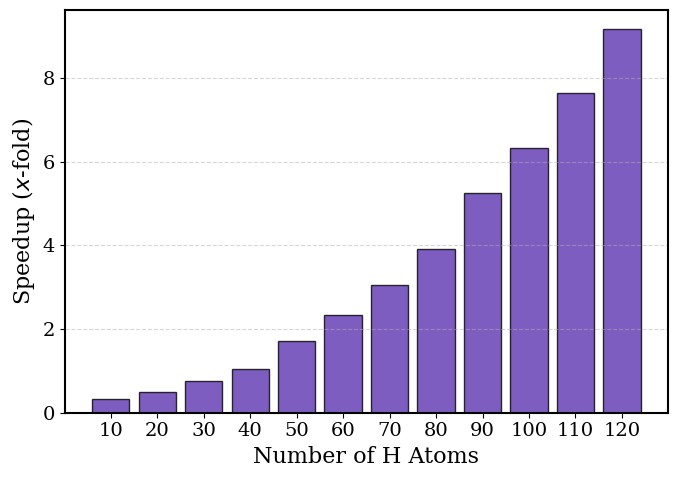

All individual plots successfully saved to the 'publication_plots' directory.


In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif', # Standard for LaTeX publications
    'figure.dpi': 100       # Screen DPI for plt.show()
})

# =============================================================================
# 1. DATA EXTRACTION & RIGOROUS FITTING UTILITIES
# =============================================================================
HA_TO_KCAL = 627.509

def power_law_with_overhead(x, a, b, c):
    """Rigorous scaling function: y = a * x^b + c"""
    return a * (x**b) + c

def get_scaling_exponent(x, y):
    """Fits y = a * x^b + c using non-linear least squares with relative weighting."""
    if len(x) < 3: 
        return np.array([]), np.array([]), 0, 0
    
    # Smarter initial guesses: 'a' small, 'b' around 3, 'c' small overhead
    p0 = [1e-5, 3.0, min(y) * 0.5]
    
    # Bounds: all positive. Cap 'b' at 10 to prevent runaway exponents
    bounds = ([0, 0, 0], [np.inf, 10.0, min(y)]) 
    
    try:
        # sigma=y weights the fit by the y-values, minimizing relative error
        popt, pcov = curve_fit(
            power_law_with_overhead, 
            x, y, 
            p0=p0, 
            bounds=bounds, 
            sigma=y,               
            absolute_sigma=False, 
            maxfev=50000
        )
        a, b, c = popt
    except RuntimeError:
        print("Warning: Optimal parameters not found, falling back to log-log fit.")
        log_x, log_y = np.log(x), np.log(y)
        b, log_a = np.polyfit(log_x, log_y, 1)
        a = np.exp(log_a)
        c = 0

    # Generate smooth curve for plotting
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law_with_overhead(x_fit, a, b, c)
    
    return x_fit, y_fit, a, b

data = []
dirs = glob.glob("../H_*_GNN-MB")

for d in dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N": n_atoms, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        print(f"Skipping {d}: {e}")

data = sorted(data, key=lambda x: x["N"])

# =============================================================================
# 2. DATA UNPACKING & RIGOROUS ERROR PROPAGATION
# =============================================================================
valid_data = []
for d in data:
    has_gnn_blocks = "raw_block_energies" in d["gnn"].get("results", {})
    has_class_blocks = "raw_block_energies" in d["classical"].get("results", {})
    
    if has_gnn_blocks and has_class_blocks:
        valid_data.append(d)
    else:
        print(f"⚠️ Warning: 'raw_block_energies' missing for H_{d['N']}. Skipping.")

data = valid_data 
N_vals = np.array([d["N"] for d in data])

if len(N_vals) == 0:
    print("Error: No valid JSON files with 'raw_block_energies' found. Exiting.")
    exit()

def safe_extract(d, backend, key):
    proxy = d[backend].get("local_energy_proxy", {})
    val = proxy.get(key)
    if val is None and backend == "gnn" and key == "total_intrinsic_memory_mb":
        return proxy.get("model_weights_mb", 0.0) + proxy.get("graph_batch_mb", 0.0)
    return val if val is not None else 0.0

time_gnn = np.array([safe_extract(d, "gnn", "avg_time_sec") for d in data])
time_class = np.array([safe_extract(d, "classical", "avg_time_sec") for d in data])

mem_gnn = np.array([safe_extract(d, "gnn", "total_intrinsic_memory_mb") for d in data])
mem_class = np.array([safe_extract(d, "classical", "total_intrinsic_memory_mb") for d in data])

energy_diff_kcal_list = []
energy_err_kcal_list = []

for d in data:
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"])
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"])
    e_diff = (raw_gnn - raw_class).flatten()
    
    try:
        df_diff_ac = reblock_by_autocorr(e_diff, name="E_Diff", verbose=0)
    except TypeError:
        df_diff_ac = reblock_by_autocorr(e_diff, verbose=0)
        
    mean_diff_ha = float(df_diff_ac.iloc[0, 0])
    error_diff_ha = float(df_diff_ac.iloc[0, 1])
    
    energy_diff_kcal_list.append(np.abs(mean_diff_ha) * HA_TO_KCAL)
    energy_err_kcal_list.append(error_diff_ha * HA_TO_KCAL)

energy_diff_kcal = np.array(energy_diff_kcal_list)
energy_err_kcal = np.array(energy_err_kcal_list)

error_per_atom_kcal = energy_diff_kcal / N_vals
err_per_atom_bars_kcal = energy_err_kcal / N_vals

# =============================================================================
# 3. INDIVIDUAL PLOTTING 
# =============================================================================
c_gnn, c_class = '#D81B60', '#1E88E5'
cap = 5

os.makedirs("publication_plots", exist_ok=True)





# --- Plot 5: Speedup Factor ---
plt.figure(figsize=(7, 5))
speedup = time_class / time_gnn
plt.bar(N_vals.astype(str), speedup, color='#5E35B1', alpha=0.8, edgecolor='black')
plt.xlabel('Number of H Atoms')
plt.ylabel('Speedup ($x$-fold)')
plt.grid(axis='y', ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("publication_plots/Speedup_Factor.pdf", bbox_inches='tight')
plt.show()

print("All individual plots successfully saved to the 'publication_plots' directory.")

Hydrogen publication-ready plots saved to 'hydrogen_publication_plots/'.


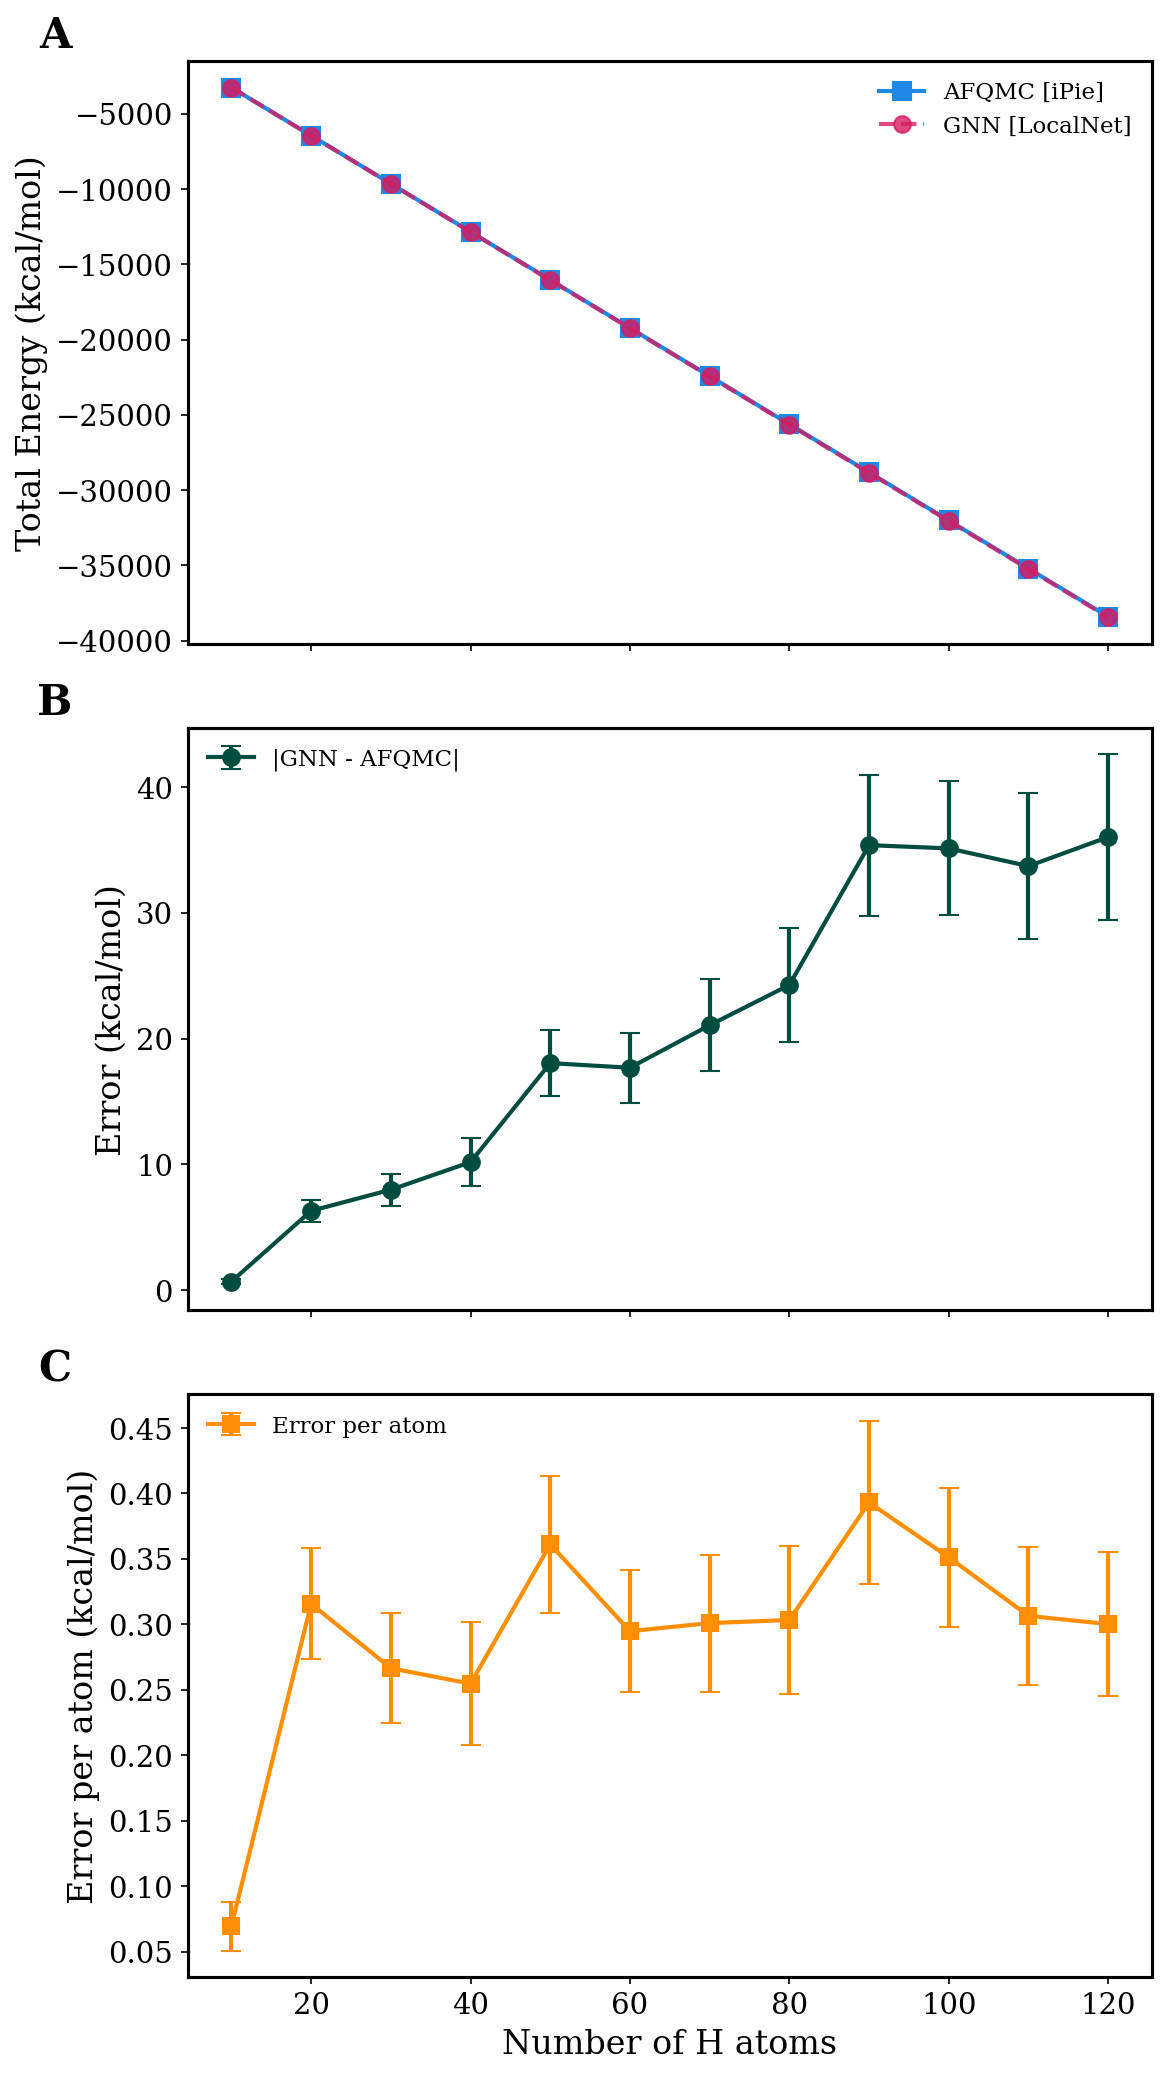

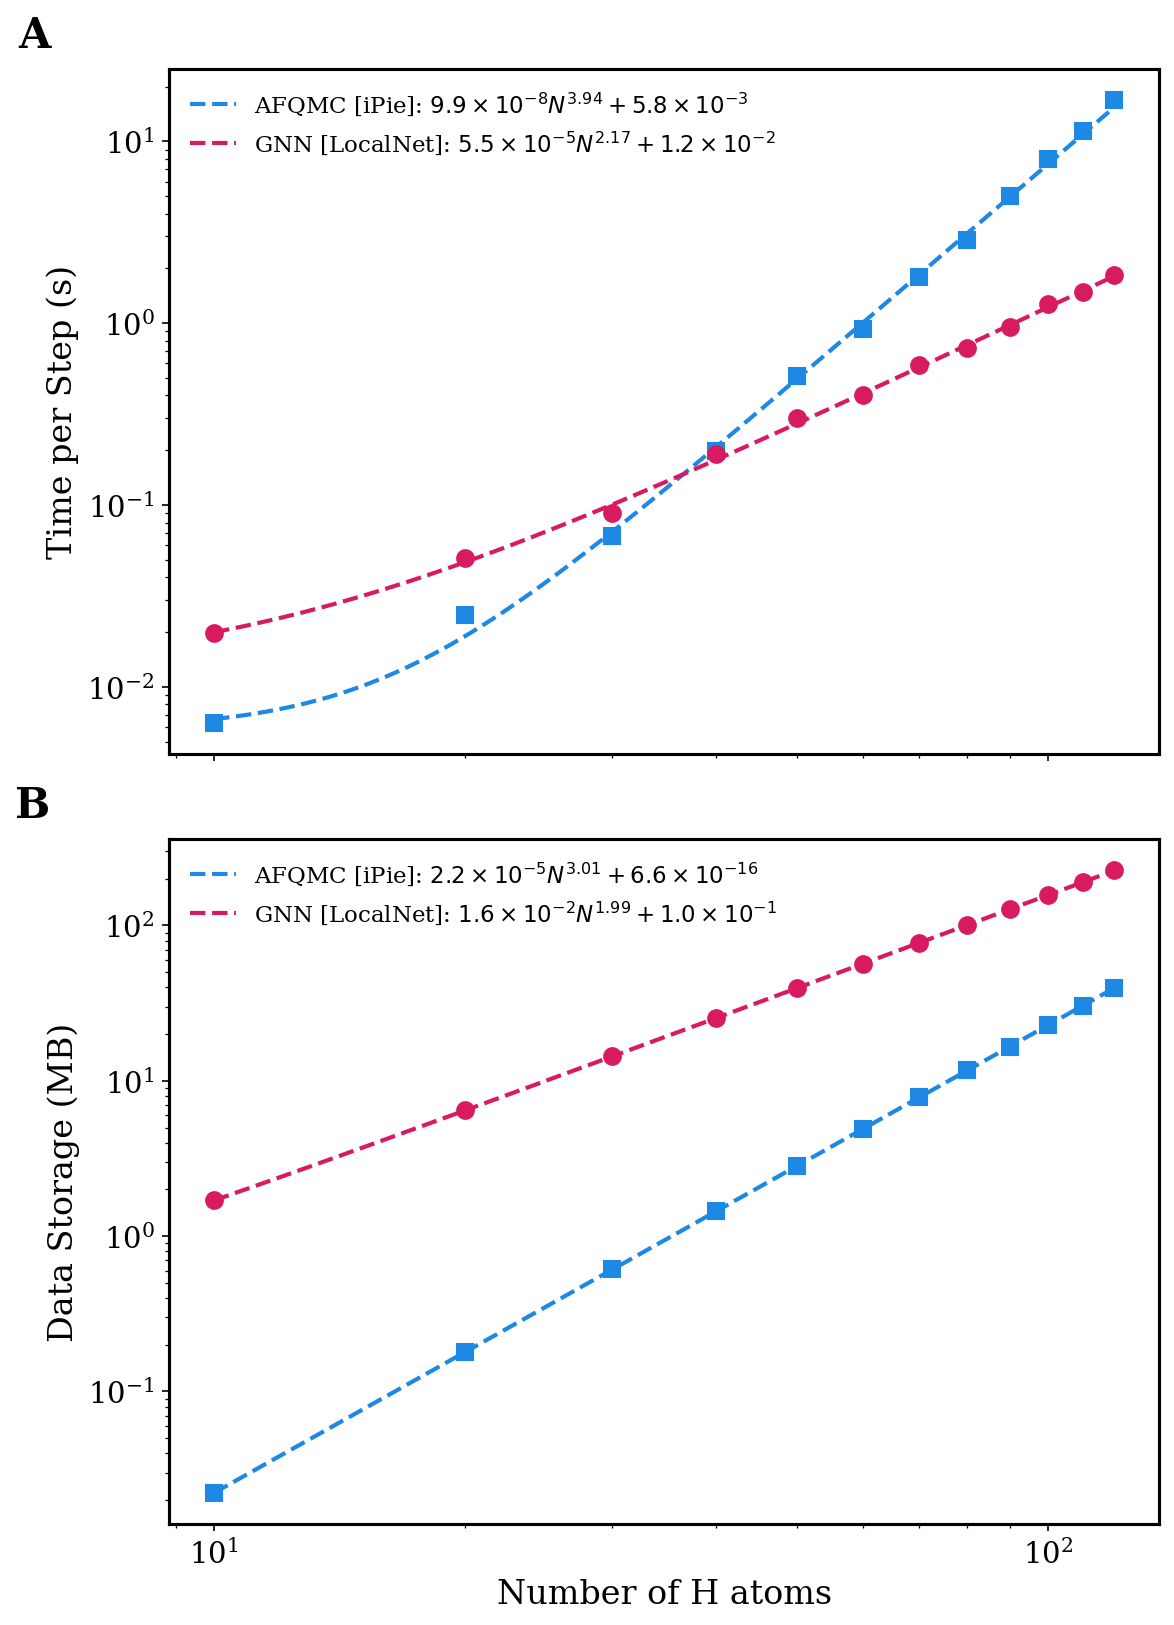

In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 11,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif',
    'figure.dpi': 150
})

HA_TO_KCAL = 627.509
c_gnn, c_class = '#D81B60', '#1E88E5'
cap = 5

# =============================================================================
# 1. UTILITIES
# =============================================================================
def power_law_with_overhead(x, a, b, c):
    """Full model: y = a * x^b + c"""
    return a * (x**b) + c

def get_scaling_exponent(x, y):
    """Rigorous fit returning a, b, and the overhead c."""
    if len(x) < 3: return np.array([]), np.array([]), 0, 0, 0
    p0 = [1e-5, 3.0, min(y) * 0.1]
    bounds = ([0, 0, 0], [np.inf, 10.0, min(y)])
    try:
        popt, _ = curve_fit(power_law_with_overhead, x, y, p0=p0, bounds=bounds, 
                            sigma=y, absolute_sigma=False, maxfev=50000)
        a, b, c = popt
    except:
        # Fallback to simple power law if overhead fit fails
        log_x, log_y = np.log(x), np.log(y)
        b, log_a = np.polyfit(log_x, log_y, 1)
        a, c = np.exp(log_a), 0
    
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law_with_overhead(x_fit, a, b, c)
    return x_fit, y_fit, a, b, c

def format_sci_latex(num):
    """Converts a number from 'e' format into proper LaTeX scientific notation."""
    if num == 0:
        return "0"
    s = f"{num:.1e}"
    base, exponent = s.split('e')
    return f"{base} \\times 10^{{{int(exponent)}}}"

def add_panel_label(ax, label):
    """Adds bold A/B/C labels to the top left of the axis."""
    ax.text(-0.12, 1.08, label, transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')

# =============================================================================
# 2. DATA EXTRACTION
# =============================================================================
data_dirs = sorted(glob.glob("../H_*_GNN-MB"), key=lambda x: int(x.split('_')[1]))
N_vals = []
time_gnn, time_class = [], []
mem_gnn, mem_class = [], []
e_diff_kcal, e_err_kcal = [], []
e_gnn_ha, e_class_ha = [], []

for d in data_dirs:
    try:
        n_atoms = int(d.split('_')[1])
        gnn_f = os.path.join(d, f"scaling_metrics_GNN_H{n_atoms}.json")
        cls_f = os.path.join(d, f"scaling_metrics_Classical_H{n_atoms}.json")
        
        if os.path.exists(gnn_f) and os.path.exists(cls_f):
            with open(gnn_f, 'r') as f: gnn_m = json.load(f)
            with open(cls_f, 'r') as f: cls_m = json.load(f)
            
            # Energy Data
            rg = np.array(gnn_m["results"]["raw_block_energies"])
            rc = np.array(cls_m["results"]["raw_block_energies"])
            e_gnn_ha.append(np.mean(rg))
            e_class_ha.append(np.mean(rc))
            
            # Error Propagation
            diff = (rg - rc).flatten()
            df_ac = reblock_by_autocorr(diff, verbose=0)
            e_diff_kcal.append(np.abs(float(df_ac.iloc[0, 0])) * HA_TO_KCAL)
            e_err_kcal.append(float(df_ac.iloc[0, 1]) * HA_TO_KCAL)
            
            # Scaling Data
            pg = gnn_m.get("local_energy_proxy", {})
            pc = cls_m.get("local_energy_proxy", {})
            time_gnn.append(pg.get("avg_time_sec", 0))
            time_class.append(pc.get("avg_time_sec", 0))
            
            mg = pg.get("total_intrinsic_memory_mb")
            if mg is None: mg = pg.get("model_weights_mb", 0) + pg.get("graph_batch_mb", 0)
            mem_gnn.append(mg)
            mem_class.append(pc.get("total_intrinsic_memory_mb", 0))
            
            N_vals.append(n_atoms)
    except Exception as e:
        print(f"Skipping {d}: {e}")

N_vals = np.array(N_vals)
os.makedirs("hydrogen_publication_plots", exist_ok=True)

# =============================================================================
# 3. HYDROGEN ACCURACY COMBINED (FIGURE 1)
# =============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

# Convert total energies from Hartree to kcal/mol
e_class_kcal = np.array(e_class_ha) * HA_TO_KCAL
e_gnn_kcal = np.array(e_gnn_ha) * HA_TO_KCAL

# Panel A: Total Energy
ax1.plot(N_vals, e_class_kcal, 's-', color=c_class, label='AFQMC [iPie]', markersize=9)
ax1.plot(N_vals, e_gnn_kcal, 'o--', color=c_gnn, label='GNN [LocalNet]', alpha=0.8)
ax1.set_ylabel('Total Energy (kcal/mol)')
ax1.legend(frameon=False)
add_panel_label(ax1, "A")

# Panel B: Error
ax2.errorbar(N_vals, e_diff_kcal, yerr=e_err_kcal, fmt='-o', color='#004D40', capsize=cap, label='|GNN - AFQMC|')
ax2.set_ylabel('Error (kcal/mol)')
ax2.legend(frameon=False)
add_panel_label(ax2, "B")

# Panel C: Error Per Atom
ax3.errorbar(N_vals, np.array(e_diff_kcal)/N_vals, yerr=np.array(e_err_kcal)/N_vals, fmt='-s', color='#FF8F00', capsize=cap, label='Error per atom')
ax3.set_xlabel('Number of H atoms')
ax3.set_ylabel('Error per atom (kcal/mol)')
ax3.legend(frameon=False)
add_panel_label(ax3, "C")

plt.tight_layout()
plt.savefig("hydrogen_publication_plots/Hydrogen_Accuracy_Combined.pdf", bbox_inches='tight')

# =============================================================================
# 4. HYDROGEN SCALING COMBINED (FIGURE 2)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 11), sharex=True)

# Panel A: Time Scaling
xf, yf, a, b, c = get_scaling_exponent(N_vals, time_class)
ax1.plot(N_vals, time_class, 's', color=c_class)
ax1.plot(xf, yf, '--', color=c_class, label=fr'AFQMC [iPie]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')

xf, yf, a, b, c = get_scaling_exponent(N_vals, time_gnn)
ax1.plot(N_vals, time_gnn, 'o', color=c_gnn)
ax1.plot(xf, yf, '--', color=c_gnn, label=fr'GNN [LocalNet]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')
ax1.set_yscale('log')
ax1.set_ylabel('Time per Step (s)')
ax1.legend(frameon=False)
add_panel_label(ax1, "A")

# Panel B: Memory Scaling
xf, yf, a, b, c = get_scaling_exponent(N_vals, mem_class)
ax2.plot(N_vals, mem_class, 's', color=c_class)
ax2.plot(xf, yf, '--', color=c_class, label=fr'AFQMC [iPie]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')

xf, yf, a, b, c = get_scaling_exponent(N_vals, mem_gnn)
ax2.plot(N_vals, mem_gnn, 'o', color=c_gnn)
ax2.plot(xf, yf, '--', color=c_gnn, label=fr'GNN [LocalNet]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of H atoms')
ax2.set_ylabel('Data Storage (MB)')
ax2.legend(frameon=False)
add_panel_label(ax2, "B")

plt.tight_layout()
plt.savefig("hydrogen_publication_plots/Hydrogen_Scaling_Combined.pdf", bbox_inches='tight')

print("Hydrogen publication-ready plots saved to 'hydrogen_publication_plots/'.")